In [1]:
!pip install opencv-python tqdm tensorflow scikit-learn matplotlib seaborn

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

print(" Semua library berhasil diimport!")

 Semua library berhasil diimport!


In [3]:
# Download dataset dari Kaggle
!kaggle datasets download dhruvmak/font-recognition-data

# Extract file zip
import zipfile
with zipfile.ZipFile('font-recognition-data.zip', 'r') as zip_ref:
    zip_ref.extractall('font_data')

print(" Dataset berhasil di download dan extract!")

Dataset URL: https://www.kaggle.com/datasets/dhruvmak/font-recognition-data
License(s): CC0-1.0
100% 1.27G/1.27G [00:14<00:00, 94.4MB/s]

 Dataset berhasil di download dan extract!


In [4]:
# Install kaggle library terlebih dahulu
!pip install kaggle

# Buat folder kaggle
!mkdir -p ~/.kaggle

# Upload kaggle.json (API key dari Kaggle)
from google.colab import files
print(" Upload file kaggle.json Anda:")
print("(Jika tidak punya, download dari Kaggle.com → Account → Create API Token)")
uploaded = files.upload()

# Pindahkan kaggle.json ke folder yang benar
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
print("\n Download dataset dari Kaggle...")
!kaggle datasets download dhruvmak/font-recognition-data

# Extract file zip
import zipfile
import os

print("\n Extract file zip...")
with zipfile.ZipFile('font-recognition-data.zip', 'r') as zip_ref:
    zip_ref.extractall('font_data')

# Lihat struktur folder
print("\n Struktur folder font_data:")
!ls -la font_data/

# Cek folder yang tersedia
print("\n Folder yang tersedia:")
for item in os.listdir('font_data'):
    print(f"   - {item}")

 Upload file kaggle.json Anda:
(Jika tidak punya, download dari Kaggle.com → Account → Create API Token)


Saving Image_9.jpg to Image_9.jpg
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory

 Download dataset dari Kaggle...
Dataset URL: https://www.kaggle.com/datasets/dhruvmak/font-recognition-data
License(s): CC0-1.0
font-recognition-data.zip: Skipping, found more recently modified local copy (use --force to force download)

 Extract file zip...

 Struktur folder font_data:
total 16
drwxr-xr-x  4 root root 4096 May 18 13:19  .
drwxr-xr-x  1 root root 4096 May 18 13:21  ..
drwxr-xr-x 50 root root 4096 May 18 13:19 'Font Dataset Large'
drwxr-xr-x 50 root root 4096 May 18 13:19 'Font Dataset Large Color'

 Folder yang tersedia:
   - Font Dataset Large
   - Font Dataset Large Color


In [5]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def load_image(filenames, path):
    """
    Memuat gambar dari path yang diberikan
    """
    images = []
    for filename in tqdm(filenames, desc=f"Loading {os.path.basename(path)}"):
        file_path = os.path.join(path, filename)
        image = cv2.imread(file_path)
        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            images.append(image)
    return images

# Tentukan path yang benar
base_path = 'font_data/Font Dataset Large'  # Gunakan folder yang berisi gambar

print("="*50)
print("CEK STRUKTUR FOLDER")
print("="*50)

# Lihat isi folder Font Dataset Large
print("\n Isi folder 'Font Dataset Large':")
if os.path.exists(base_path):
    folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
    print(f"Folder yang ditemukan: {folders[:10]}... (total {len(folders)} folder)")

    # Cari folder font yang dibutuhkan
    font_folders = []
    for folder in folders:
        if any(font in folder.lower() for font in ['arial', 'brandish', 'consolas', 'didot']):
            font_folders.append(folder)

    print(f"\n Folder font yang ditemukan:")
    for f in font_folders:
        print(f"   - {f}")

    # Tentukan path untuk setiap font
    font_paths = {}
    for folder in folders:
        folder_lower = folder.lower()
        if 'arial' in folder_lower:
            font_paths['Arial'] = os.path.join(base_path, folder)
        elif 'brandish' in folder_lower:
            font_paths['Brandish'] = os.path.join(base_path, folder)
        elif 'consolas' in folder_lower:
            font_paths['Consolas'] = os.path.join(base_path, folder)
        elif 'didot' in folder_lower:
            font_paths['Didot'] = os.path.join(base_path, folder)

    # Jika tidak ditemukan, ambil 4 folder pertama
    if len(font_paths) < 4:
        print("\n Folder spesifik tidak ditemukan, menggunakan 4 folder pertama...")
        font_paths = {
            'Arial': os.path.join(base_path, folders[0]),
            'Brandish': os.path.join(base_path, folders[1]),
            'Consolas': os.path.join(base_path, folders[2]),
            'Didot': os.path.join(base_path, folders[3])
        }
else:
    print(f" Folder '{base_path}' tidak ditemukan!")
    # Coba cari folder lain
    if os.path.exists('font_data/Font Dataset Large Color'):
        base_path = 'font_data/Font Dataset Large Color'
        print(f" Menggunakan folder alternatif: {base_path}")
    else:
        print(" Gunakan folder 'Font Dataset Large' atau 'Font Dataset Large Color'")

# Assign path
arial_path = font_paths.get('Arial')
brandish_path = font_paths.get('Brandish')
consolas_path = font_paths.get('Consolas')
didot_path = font_paths.get('Didot')

print("\n" + "="*50)
print("PATH FOLDER FONT")
print("="*50)
for name, path in font_paths.items():
    if os.path.exists(path):
        file_count = len(os.listdir(path))
        print(f" {name}: {path} ({file_count} gambar)")
    else:
        print(f" {name}: {path} - TIDAK DITEMUKAN!")

# Load gambar
print("\n" + "="*50)
print("LOAD GAMBAR")
print("="*50)

arial_files = os.listdir(arial_path) if arial_path and os.path.exists(arial_path) else []
brandish_files = os.listdir(brandish_path) if brandish_path and os.path.exists(brandish_path) else []
consolas_files = os.listdir(consolas_path) if consolas_path and os.path.exists(consolas_path) else []
didot_files = os.listdir(didot_path) if didot_path and os.path.exists(didot_path) else []

print(f" Jumlah file:")
print(f"   - Arial    : {len(arial_files)} gambar")
print(f"   - Brandish : {len(brandish_files)} gambar")
print(f"   - Consolas : {len(consolas_files)} gambar")
print(f"   - Didot    : {len(didot_files)} gambar")

# Load semua gambar
print("\n Memuat gambar...")
arial_images = load_image(arial_files, arial_path) if arial_files else []
brandish_images = load_image(brandish_files, brandish_path) if brandish_files else []
consolas_images = load_image(consolas_files, consolas_path) if consolas_files else []
didot_images = load_image(didot_files, didot_path) if didot_files else []

print(f"\n Gambar berhasil dimuat:")
print(f"   - Arial    : {len(arial_images)} gambar")
print(f"   - Brandish : {len(brandish_images)} gambar")
print(f"   - Consolas : {len(consolas_images)} gambar")
print(f"   - Didot    : {len(didot_images)} gambar")

CEK STRUKTUR FOLDER

 Isi folder 'Font Dataset Large':
Folder yang ditemukan: ['Corbel', 'Comic Sans MS', 'Helvetica', 'Agency', 'Sabon', 'Steppes TT', 'Century', 'Akzidenz Grotesk', 'Book Antiqua', 'Perpetua']... (total 48 folder)

 Folder font yang ditemukan:
   - Didot
   - Consolas
   - Arial
   - Brandish

PATH FOLDER FONT
 Didot: font_data/Font Dataset Large/Didot (5000 gambar)
 Consolas: font_data/Font Dataset Large/Consolas (5000 gambar)
 Arial: font_data/Font Dataset Large/Arial (5000 gambar)
 Brandish: font_data/Font Dataset Large/Brandish (5000 gambar)

LOAD GAMBAR
 Jumlah file:
   - Arial    : 5000 gambar
   - Brandish : 5000 gambar
   - Consolas : 5000 gambar
   - Didot    : 5000 gambar

 Memuat gambar...


Loading Didot: 100%|██████████| 5000/5000 [00:00<00:00, 8662.35it/s]


 Gambar berhasil dimuat:
   - Arial    : 5000 gambar
   - Brandish : 5000 gambar
   - Consolas : 5000 gambar
   - Didot    : 5000 gambar


In [6]:
# Cek ukuran setiap gambar
heights = []
widths = []

for image in arial_images:
    height = image.shape[0]
    width = image.shape[1]
    heights.append(height)
    widths.append(width)


print("STATISTIK UKURAN GAMBAR")
print("="*50)
print(f"Tinggi (height) - Max: {max(heights) if heights else 0} px, Min: {min(heights) if heights else 0} px")
print(f"Lebar (width)  - Max: {max(widths) if widths else 0} px, Min: {min(widths) if widths else 0} px")

# Fungsi untuk resize gambar ke 80 pixel (lebar)
def take_80_pixels(images_list):
    """
    Memotong gambar menjadi lebar 80 pixel
    """
    new_images = []
    for image in images_list:
        if image.shape[1] >= 80:
            # Ambil 80 pixel pertama dari lebar
            new_images.append(image[:, :80])
        else:
            # Jika kurang dari 80, resize ke 80
            resized = cv2.resize(image, (80, image.shape[0]))
            new_images.append(resized[:, :80])
    return np.array(new_images)

# Resize semua gambar ke lebar 80 pixel
print("\n Menyamakan ukuran gambar ke 80 pixel...")
arial_80 = take_80_pixels(arial_images)
brandish_80 = take_80_pixels(brandish_images)
consolas_80 = take_80_pixels(consolas_images)
didot_80 = take_80_pixels(didot_images)

# Cek shape setelah resize
print(f"\n Shape setelah resize:")
print(f"   - Arial    : {arial_80.shape}")
print(f"   - Brandish : {brandish_80.shape}")
print(f"   - Consolas : {consolas_80.shape}")
print(f"   - Didot    : {didot_80.shape}")

# Jika ada yang kosong, gunakan data minimal
if len(arial_80) == 0 or len(brandish_80) == 0 or len(consolas_80) == 0 or len(didot_80) == 0:
    print("\n Peringatan: Ada folder yang kosong!")
    print("Menggunakan data yang tersedia...")

STATISTIK UKURAN GAMBAR
Tinggi (height) - Max: 32 px, Min: 32 px
Lebar (width)  - Max: 248 px, Min: 30 px

 Menyamakan ukuran gambar ke 80 pixel...

 Shape setelah resize:
   - Arial    : (5000, 32, 80)
   - Brandish : (5000, 32, 80)
   - Consolas : (5000, 32, 80)
   - Didot    : (5000, 32, 80)


In [7]:
# Membuat label untuk setiap gambar
# 0 = Arial, 1 = Brandish, 2 = Consolas, 3 = Didot

labels = [0] * len(arial_80) + \
         [1] * len(brandish_80) + \
         [2] * len(consolas_80) + \
         [3] * len(didot_80)


print("PEMBUATAN LABEL")
print("="*50)
print(f"Total label: {len(labels)}")
print(f"Distribusi label:")
print(f"   - Arial (0)    : {labels.count(0)}")
print(f"   - Brandish (1) : {labels.count(1)}")
print(f"   - Consolas (2) : {labels.count(2)}")
print(f"   - Didot (3)    : {labels.count(3)}")

PEMBUATAN LABEL
Total label: 20000
Distribusi label:
   - Arial (0)    : 5000
   - Brandish (1) : 5000
   - Consolas (2) : 5000
   - Didot (3)    : 5000


In [8]:
# Gabungkan semua gambar
all_images = np.concatenate([arial_80, brandish_80, consolas_80, didot_80], axis=0)

# Tambahkan channel dimension (untuk CNN)
all_images = all_images.reshape(all_images.shape[0], all_images.shape[1], all_images.shape[2], 1)

print(f"\n Dataset akhir:")
print(f"   - Total gambar: {all_images.shape[0]}")
print(f"   - Shape gambar: {all_images.shape[1]} x {all_images.shape[2]} pixel")
print(f"   - Channel: {all_images.shape[3]} (grayscale)")


 Dataset akhir:
   - Total gambar: 20000
   - Shape gambar: 32 x 80 pixel
   - Channel: 1 (grayscale)


In [9]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Split data (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(
    all_images,
    labels,
    test_size=0.3,
    random_state=88,
    stratify=labels
)


print("TRAIN TEST SPLIT")
print("="*50)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {len(y_train)}")
print(f"y_test shape : {len(y_test)}")

# Konversi label ke one-hot encoding
y_train_onehot = to_categorical(y_train, num_classes=4)
y_test_onehot = to_categorical(y_test, num_classes=4)

print(f"\n Label berhasil di-convert ke one-hot encoding")
print(f"   - Contoh label asli: {y_train[0]} → {y_train_onehot[0]}")

TRAIN TEST SPLIT
X_train shape: (14000, 32, 80, 1)
X_test shape : (6000, 32, 80, 1)
y_train shape: 14000
y_test shape : 6000

 Label berhasil di-convert ke one-hot encoding
   - Contoh label asli: 3 → [0. 0. 0. 1.]


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

# Input shape
input_shape = (X_train.shape[1], X_train.shape[2], 1)


print("ARSITEKTUR CNN")
print("="*50)
print(f"Input shape: {input_shape}")

# Membangun model CNN
model = Sequential()

# Layer 1: Conv2D
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu',
                 padding='same', input_shape=input_shape))

# Layer 2: Conv2D
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))

# Layer 3: MaxPooling
model.add(MaxPool2D(pool_size=(2, 2)))

# Layer 4: Dropout
model.add(Dropout(0.25))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(4, activation='softmax'))  # 4 classes

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\n" + "="*50)
print("SUMMARY MODEL CNN")
print("="*50)
model.summary()

ARSITEKTUR CNN
Input shape: (32, 80, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



SUMMARY MODEL CNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 40960)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,243,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,270,340 (20.10 MB)

 Trainable params: 5,270,340 (20.10 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Training model

print("TRAINING MODEL CNN")
print("="*50)

history = model.fit(
    X_train, y_train_onehot,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test_onehot),
    verbose=1
)

print("\n Training selesai!")

TRAINING MODEL CNN
Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 160s 365ms/step - accuracy: 0.9921 - loss: 0.0311 - val_accuracy: 0.9968 - val_loss: 0.0096
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 200s 362ms/step - accuracy: 0.9931 - loss: 0.0296 - val_accuracy: 0.9975 - val_loss: 0.0095
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 213s 386ms/step - accuracy: 0.9952 - loss: 0.0209 - val_accuracy: 0.9995 - val_loss: 0.0025
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 196s 372ms/step - accuracy: 0.9966 - loss: 0.0138 - val_accuracy: 0.9987 - val_loss: 0.0043
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 196s 358ms/step - accuracy: 0.9961 - loss: 0.0230 - val_accuracy: 0.9975 - val_loss: 0.0216
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 200s 354ms/step - accuracy: 0.9963 - loss: 0.0218 - val_accuracy: 0.9955 - val_loss: 0.0245
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 159s 362ms/step - accuracy: 0.9966 - loss: 0.0192 - val_accuracy: 0.9993 - val_loss: 0.0016
Epoch 8/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 163s 372ms/step -

188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step
EVALUASI MODEL
 Akurasi Model: 0.9992 (99.92%)

 Classification Report:
              precision    recall  f1-score   support

       Arial       1.00      1.00      1.00      1500
    Brandish       1.00      1.00      1.00      1500
    Consolas       1.00      1.00      1.00      1500
       Didot       1.00      1.00      1.00      1500

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



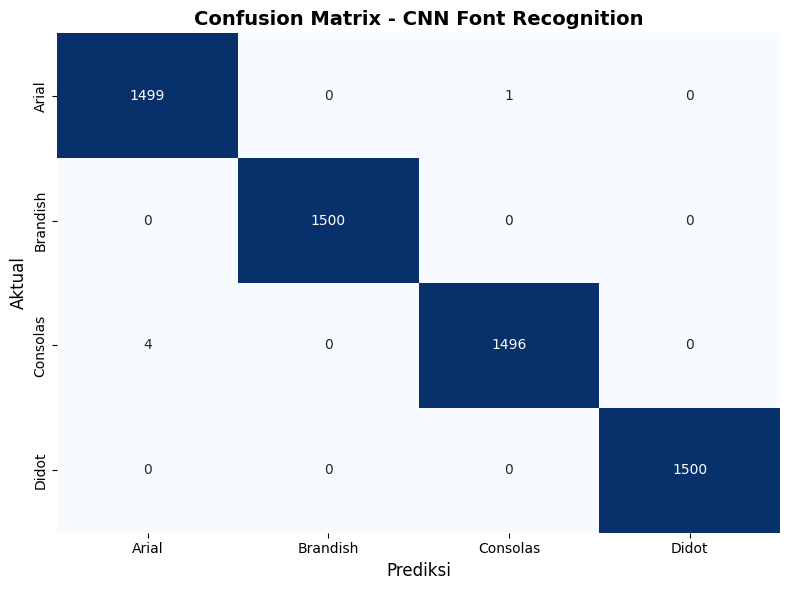


 Confusion Matrix (Numeric):
                 Prediksi
                 Arial  Brandish  Consolas  Didot
Aktual Arial      1499       0         1        0
       Brandish       0    1500         0        0
       Consolas       4       0      1496        0
       Didot          0       0         0     1500


In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prediksi pada data test
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)
y_test_true = np.argmax(y_test_onehot, axis=1)

# Hitung akurasi
accuracy = accuracy_score(y_test_true, predictions)


print("EVALUASI MODEL")
print("="*50)
print(f" Akurasi Model: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification Report
print(f"\n Classification Report:")
print(classification_report(y_test_true, predictions,
                           target_names=['Arial', 'Brandish', 'Consolas', 'Didot']))

#  CONFUSION MATRIX
# Buat confusion matrix
cm = confusion_matrix(y_test_true, predictions)

# Label names
label_names = ['Arial', 'Brandish', 'Consolas', 'Didot']

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=label_names, yticklabels=label_names,
            cmap=plt.cm.Blues)

plt.title('Confusion Matrix - CNN Font Recognition', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

# Print nilai confusion matrix
print("\n Confusion Matrix (Numeric):")
print("                 Prediksi")
print("                 Arial  Brandish  Consolas  Didot")
print(f"Aktual Arial     {cm[0][0]:5}   {cm[0][1]:5}     {cm[0][2]:5}    {cm[0][3]:5}")
print(f"       Brandish   {cm[1][0]:5}   {cm[1][1]:5}     {cm[1][2]:5}    {cm[1][3]:5}")
print(f"       Consolas   {cm[2][0]:5}   {cm[2][1]:5}     {cm[2][2]:5}    {cm[2][3]:5}")
print(f"       Didot      {cm[3][0]:5}   {cm[3][1]:5}     {cm[3][2]:5}    {cm[3][3]:5}")

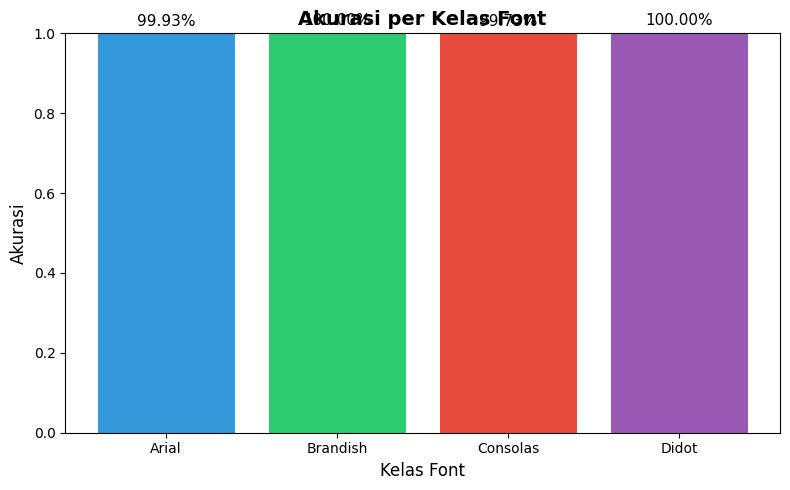


 Akurasi per Kelas:
   - Arial: 99.93%
   - Brandish: 100.00%
   - Consolas: 99.73%
   - Didot: 100.00%


In [14]:
# Visualisasi akurasi per kelas
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8, 5))
bars = plt.bar(label_names, class_accuracy, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
plt.ylim(0, 1)
plt.ylabel('Akurasi', fontsize=12)
plt.xlabel('Kelas Font', fontsize=12)
plt.title('Akurasi per Kelas Font', fontsize=14, fontweight='bold')

for bar, acc in zip(bars, class_accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print("\n Akurasi per Kelas:")
for i, name in enumerate(label_names):
    print(f"   - {name}: {class_accuracy[i]:.2%}")

In [15]:
# Mencari indeks misklasifikasi
misses = []
for i in range(len(predictions)):
    if y_test_true[i] != predictions[i]:
        misses.append(i)


print("INDEKS MISKLASIFIKASI")
print("="*50)
print(f"Total data test: {len(predictions)}")
print(f"Jumlah prediksi salah: {len(misses)}")
print(f"Persentase error: {len(misses)/len(predictions)*100:.2f}%")
print(f"\nIndeks misklasifikasi: {misses}")

# Tampilkan 10 indeks pertama jika banyak
if len(misses) > 10:
    print(f"\n10 indeks pertama: {misses[:10]}")

INDEKS MISKLASIFIKASI
Total data test: 6000
Jumlah prediksi salah: 5
Persentase error: 0.08%

Indeks misklasifikasi: [1232, 1457, 2780, 5152, 5553]


In [16]:
# Analisis detail misklasifikasi

print("DETAIL MISKLASIFIKASI")
print("="*50)

label_names = ['Arial', 'Brandish', 'Consolas', 'Didot']

for idx in misses[:20]:  # Tampilkan 20 pertama
    true_label = label_names[y_test_true[idx]]
    pred_label = label_names[predictions[idx]]
    print(f"Indeks {idx:4}: Aktual = {true_label:10} | Prediksi = {pred_label:10} ❌")

DETAIL MISKLASIFIKASI
Indeks 1232: Aktual = Consolas   | Prediksi = Arial      ❌
Indeks 1457: Aktual = Consolas   | Prediksi = Arial      ❌
Indeks 2780: Aktual = Consolas   | Prediksi = Arial      ❌
Indeks 5152: Aktual = Arial      | Prediksi = Consolas   ❌
Indeks 5553: Aktual = Consolas   | Prediksi = Arial      ❌


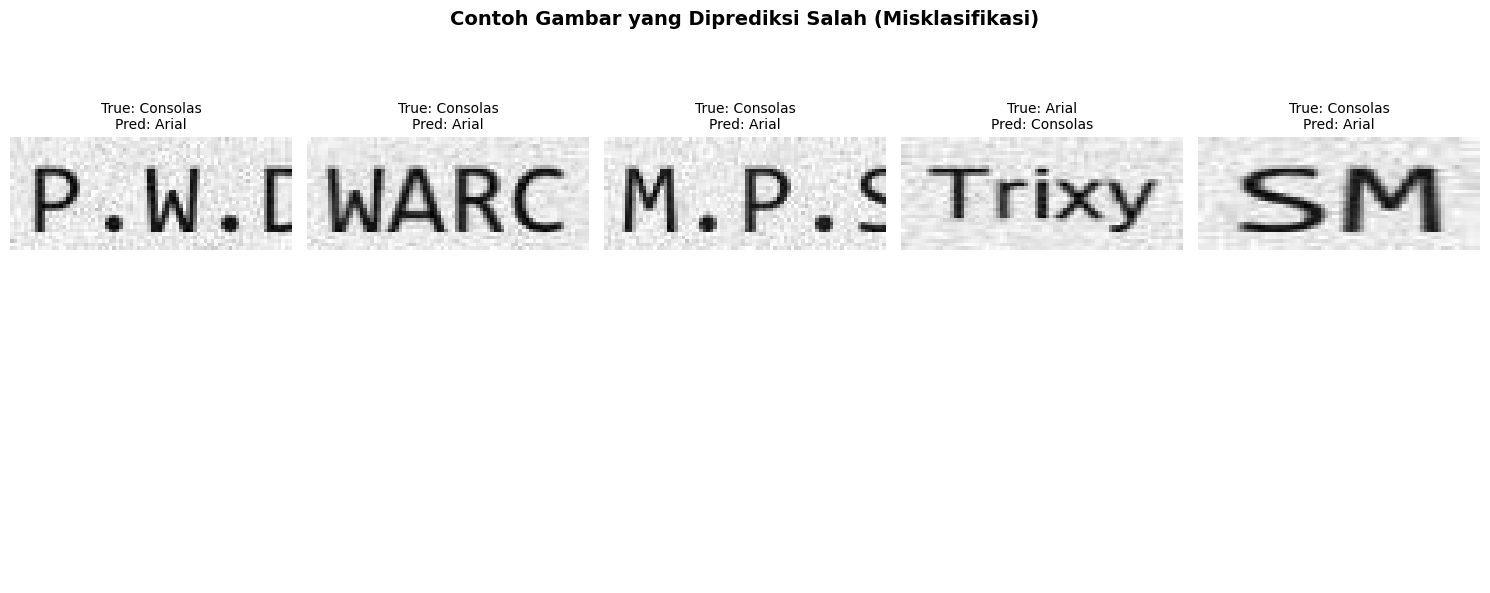

In [17]:
# Tampilkan gambar yang diprediksi salah
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

label_names = ['Arial', 'Brandish', 'Consolas', 'Didot']

for i, idx in enumerate(misses[:10]):  # Tampilkan 10 gambar pertama yang salah
    img = X_test[idx].reshape(X_test.shape[1], X_test.shape[2])
    true_label = label_names[y_test_true[idx]]
    pred_label = label_names[predictions[idx]]

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=10)
    axes[i].axis('off')

# Hapus axes yang tidak terpakai
for j in range(len(misses[:10]), len(axes)):
    axes[j].axis('off')

plt.suptitle('Contoh Gambar yang Diprediksi Salah (Misklasifikasi)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

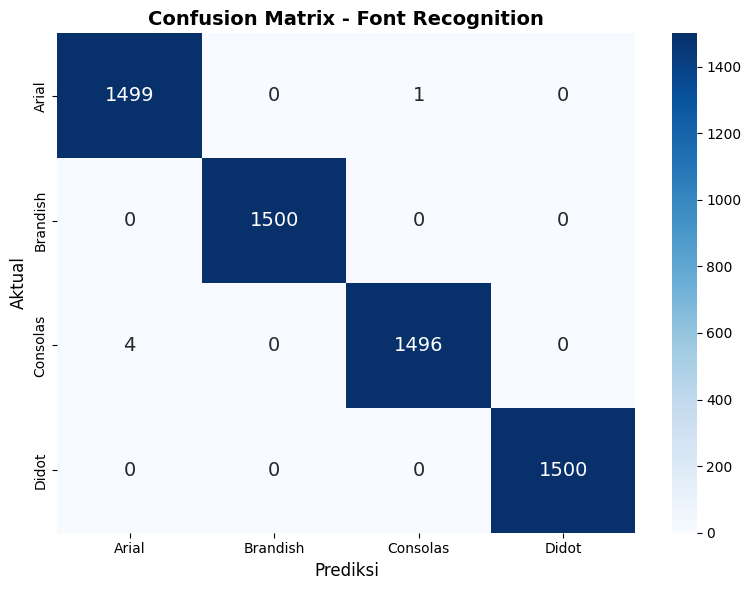


 Akurasi per Kelas:
   Arial     : 1499/1500 (99.93%)
   Brandish  : 1500/1500 (100.00%)
   Consolas  : 1496/1500 (99.73%)
   Didot     : 1500/1500 (100.00%)

 Pasangan Misklasifikasi Terbanyak:
   Consolas → Arial: 4 kali
   Arial → Consolas: 1 kali


In [18]:
# Confusion matrix dengan highlight
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_true, predictions)
label_names = ['Arial', 'Brandish', 'Consolas', 'Didot']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cbar=True,
            xticklabels=label_names, yticklabels=label_names,
            cmap='Blues', annot_kws={'size': 14})

plt.title('Confusion Matrix - Font Recognition', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

# Hitung akurasi per kelas
print("\n Akurasi per Kelas:")
for i, name in enumerate(label_names):
    correct = cm[i][i]
    total = sum(cm[i])
    accuracy = correct / total if total > 0 else 0
    print(f"   {name:10}: {correct}/{total} ({accuracy:.2%})")

# Identifikasi pasangan yang sering salah
print("\n Pasangan Misklasifikasi Terbanyak:")
errors = []
for i in range(len(label_names)):
    for j in range(len(label_names)):
        if i != j and cm[i][j] > 0:
            errors.append((label_names[i], label_names[j], cm[i][j]))

errors.sort(key=lambda x: x[2], reverse=True)
for true_label, pred_label, count in errors[:5]:
    print(f"   {true_label} → {pred_label}: {count} kali")

In [19]:
# Statistik misklasifikasi per kelas

print("STATISTIK MISKLASIFIKASI PER KELAS")
print("="*50)

label_names = ['Arial', 'Brandish', 'Consolas', 'Didot']

for i, name in enumerate(label_names):
    # Data dengan label aktual = name
    actual_indices = [idx for idx in range(len(y_test_true)) if y_test_true[idx] == i]

    # Prediksi salah dari kelas ini
    wrong_indices = [idx for idx in actual_indices if predictions[idx] != i]

    # Prediksi kemana saja
    wrong_predictions = [predictions[idx] for idx in wrong_indices]

    print(f"\n Kelas: {name}")
    print(f"   Total data: {len(actual_indices)}")
    print(f"   Prediksi salah: {len(wrong_indices)} ({len(wrong_indices)/len(actual_indices)*100:.1f}%)")

    if wrong_predictions:
        from collections import Counter
        counter = Counter(wrong_predictions)
        print(f"   Salah diprediksi sebagai:")
        for pred_class, count in counter.most_common():
            print(f"      - {label_names[pred_class]}: {count} kali")

STATISTIK MISKLASIFIKASI PER KELAS

 Kelas: Arial
   Total data: 1500
   Prediksi salah: 1 (0.1%)
   Salah diprediksi sebagai:
      - Consolas: 1 kali

 Kelas: Brandish
   Total data: 1500
   Prediksi salah: 0 (0.0%)

 Kelas: Consolas
   Total data: 1500
   Prediksi salah: 4 (0.3%)
   Salah diprediksi sebagai:
      - Arial: 4 kali

 Kelas: Didot
   Total data: 1500
   Prediksi salah: 0 (0.0%)


In [20]:
# Simpan model
model.save('font_recognition_cnn_model.h5')
print(" Model disimpan sebagai 'font_recognition_cnn_model.h5'")

# Download model
from google.colab import files
files.download('font_recognition_cnn_model.h5')

 Model disimpan sebagai 'font_recognition_cnn_model.h5'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>